# Validation Sample: Task/Contrast/Encounter (TCE) Overlap
# Scans the validation dataset and finds which (task, contrast, encounter) tuples
# are present across all subjects — without loading any NIfTI data.

In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

VAL_DIR = Path("/oak/stanford/groups/russpold/data/network_grant/validation_BIDS/derivatives/archive/output_lev1_mni")
RT_CONTRAST = "response_time"

# Tasks we care about (same 8 as discovery sample; ignore combo tasks like spatialTSWCuedTS)
TASKS_OF_INTEREST = [
    "nBack", "flanker", "directedForgetting", "goNogo",
    "shapeMatching", "stopSignal", "cuedTS", "spatialTS",
]

## 1. Discover subjects and scan available files

In [2]:
# Parse filename pattern:
# {sub}_{ses}_task-{task}_contrast-{contrast}_rtmodel-rt_centered_stat-effect-size.nii.gz
FILE_RE = re.compile(
    r"(?P<sub>sub-\S+?)_(?P<ses>ses-\d+)_task-(?P<task>\w+)_contrast-(?P<contrast>.+?)_rtmodel-rt_centered_stat-effect-size\.nii\.gz"
)

SUBJECTS = sorted(p.name for p in VAL_DIR.iterdir() if p.is_dir() and p.name.startswith("sub-"))
print(f"Found {len(SUBJECTS)} subjects: {SUBJECTS}")


Found 41 subjects: ['sub-s1035', 'sub-s1057', 'sub-s1058', 'sub-s1127', 'sub-s1134', 'sub-s1175', 'sub-s1189', 'sub-s1258', 'sub-s1267', 'sub-s1270', 'sub-s1273', 'sub-s1292', 'sub-s1314', 'sub-s1326', 'sub-s1338', 'sub-s1351', 'sub-s1391', 'sub-s1399', 'sub-s1402', 'sub-s1408', 'sub-s1445', 'sub-s1481', 'sub-s1486', 'sub-s180', 'sub-s216', 'sub-s247', 'sub-s286', 'sub-s295', 'sub-s300', 'sub-s320', 'sub-s321', 'sub-s336', 'sub-s373', 'sub-s394', 'sub-s415', 'sub-s480', 'sub-s599', 'sub-s645', 'sub-s76', 'sub-s874', 'sub-s956']


In [3]:
available_tce = {}

for sub in SUBJECTS:
    sub_tces = set()
    for task in TASKS_OF_INTEREST:
        task_dir = VAL_DIR / sub / task / "indiv_contrasts"
        if not task_dir.exists():
            continue

        # Collect (session_int, contrast) pairs for this subject+task
        session_contrast_pairs = []
        for f in task_dir.iterdir():
            m = FILE_RE.match(f.name)
            if m and m.group("task") == task and m.group("contrast") != RT_CONTRAST:
                ses_int = int(m.group("ses").replace("ses-", ""))
                session_contrast_pairs.append((ses_int, m.group("contrast")))

        # Only keep the first 5 sessions chronologically (max 5 encounters per task)
        unique_sessions = sorted(set(s for s, _ in session_contrast_pairs))
        if len(unique_sessions) > 5:
            print(f"  WARNING: {sub}/{task} has {len(unique_sessions)} sessions {unique_sessions} — keeping first 5 only")
            unique_sessions = unique_sessions[:5]
        valid_sessions = set(unique_sessions)
        ses_to_enc = {ses: f"{i+1:02d}" for i, ses in enumerate(unique_sessions)}

        for ses_int, contrast in session_contrast_pairs:
            if ses_int not in valid_sessions:
                continue
            enc = ses_to_enc[ses_int]
            sub_tces.add((task, contrast, enc))

    available_tce[sub] = sub_tces
    print(f"{sub}: {len(sub_tces)} (task, contrast, encounter) tuples")


sub-s1035: 167 (task, contrast, encounter) tuples
sub-s1057: 180 (task, contrast, encounter) tuples
sub-s1058: 180 (task, contrast, encounter) tuples
sub-s1127: 180 (task, contrast, encounter) tuples
sub-s1134: 180 (task, contrast, encounter) tuples
sub-s1175: 155 (task, contrast, encounter) tuples
sub-s1189: 180 (task, contrast, encounter) tuples
sub-s1258: 176 (task, contrast, encounter) tuples
sub-s1267: 180 (task, contrast, encounter) tuples
sub-s1270: 180 (task, contrast, encounter) tuples
sub-s1273: 180 (task, contrast, encounter) tuples
sub-s1292: 177 (task, contrast, encounter) tuples
sub-s1314: 160 (task, contrast, encounter) tuples
sub-s1326: 180 (task, contrast, encounter) tuples
sub-s1338: 180 (task, contrast, encounter) tuples
sub-s1351: 180 (task, contrast, encounter) tuples
sub-s1391: 180 (task, contrast, encounter) tuples
sub-s1399: 180 (task, contrast, encounter) tuples
sub-s1402: 180 (task, contrast, encounter) tuples
sub-s1408: 180 (task, contrast, encounter) tuples


## 2. Compute shared TCEs across all subjects

In [4]:
shared_tce = set.intersection(*available_tce.values())

# Sort deterministically: task order, then contrast alphabetically, then encounter
shared_tce_sorted = sorted(
    shared_tce,
    key=lambda tce: (TASKS_OF_INTEREST.index(tce[0]), tce[1], tce[2])
)

print(f"Shared TCEs across ALL {len(SUBJECTS)} subjects: {len(shared_tce_sorted)}\n")
for task, contrast, enc in shared_tce_sorted:
    print(f"  {task:20s}  {contrast:45s}  enc {enc}")


Shared TCEs across ALL 41 subjects: 124

  goNogo                go                                             enc 01
  goNogo                go                                             enc 02
  goNogo                go                                             enc 03
  goNogo                go                                             enc 04
  goNogo                nogo_success                                   enc 01
  goNogo                nogo_success                                   enc 02
  goNogo                nogo_success                                   enc 03
  goNogo                nogo_success                                   enc 04
  goNogo                nogo_success-go                                enc 01
  goNogo                nogo_success-go                                enc 02
  goNogo                nogo_success-go                                enc 03
  goNogo                nogo_success-go                                enc 04
  goNogo               

## 3. Per-subject coverage: how many subjects have each TCE

In [5]:
# Build a coverage dataframe: rows = TCEs, columns = subjects, values = 0/1
all_tces = sorted(
    set.union(*available_tce.values()),
    key=lambda tce: (TASKS_OF_INTEREST.index(tce[0]) if tce[0] in TASKS_OF_INTEREST else 99, tce[1], tce[2])
)

coverage = pd.DataFrame(
    {sub: [int(tce in available_tce[sub]) for tce in all_tces] for sub in SUBJECTS},
    index=[f"{t}__{c}__enc{e}" for t, c, e in all_tces]
)
coverage["n_subjects"] = coverage.sum(axis=1)
coverage_sorted = coverage.sort_values("n_subjects", ascending=False)

print(f"Total unique TCEs across all subjects: {len(all_tces)}")
print(f"TCEs present in ALL subjects: {(coverage['n_subjects'] == len(SUBJECTS)).sum()}")
print(f"TCEs present in >=80% of subjects (>={int(0.8*len(SUBJECTS))}): {(coverage['n_subjects'] >= int(0.8*len(SUBJECTS))).sum()}")
print(f"TCEs present in >=50% of subjects (>={len(SUBJECTS)//2}): {(coverage['n_subjects'] >= len(SUBJECTS)//2).sum()}")


Total unique TCEs across all subjects: 180
TCEs present in ALL subjects: 124
TCEs present in >=80% of subjects (>=32): 180
TCEs present in >=50% of subjects (>=20): 180


## 4. Heatmap: subject × task/encounter coverage

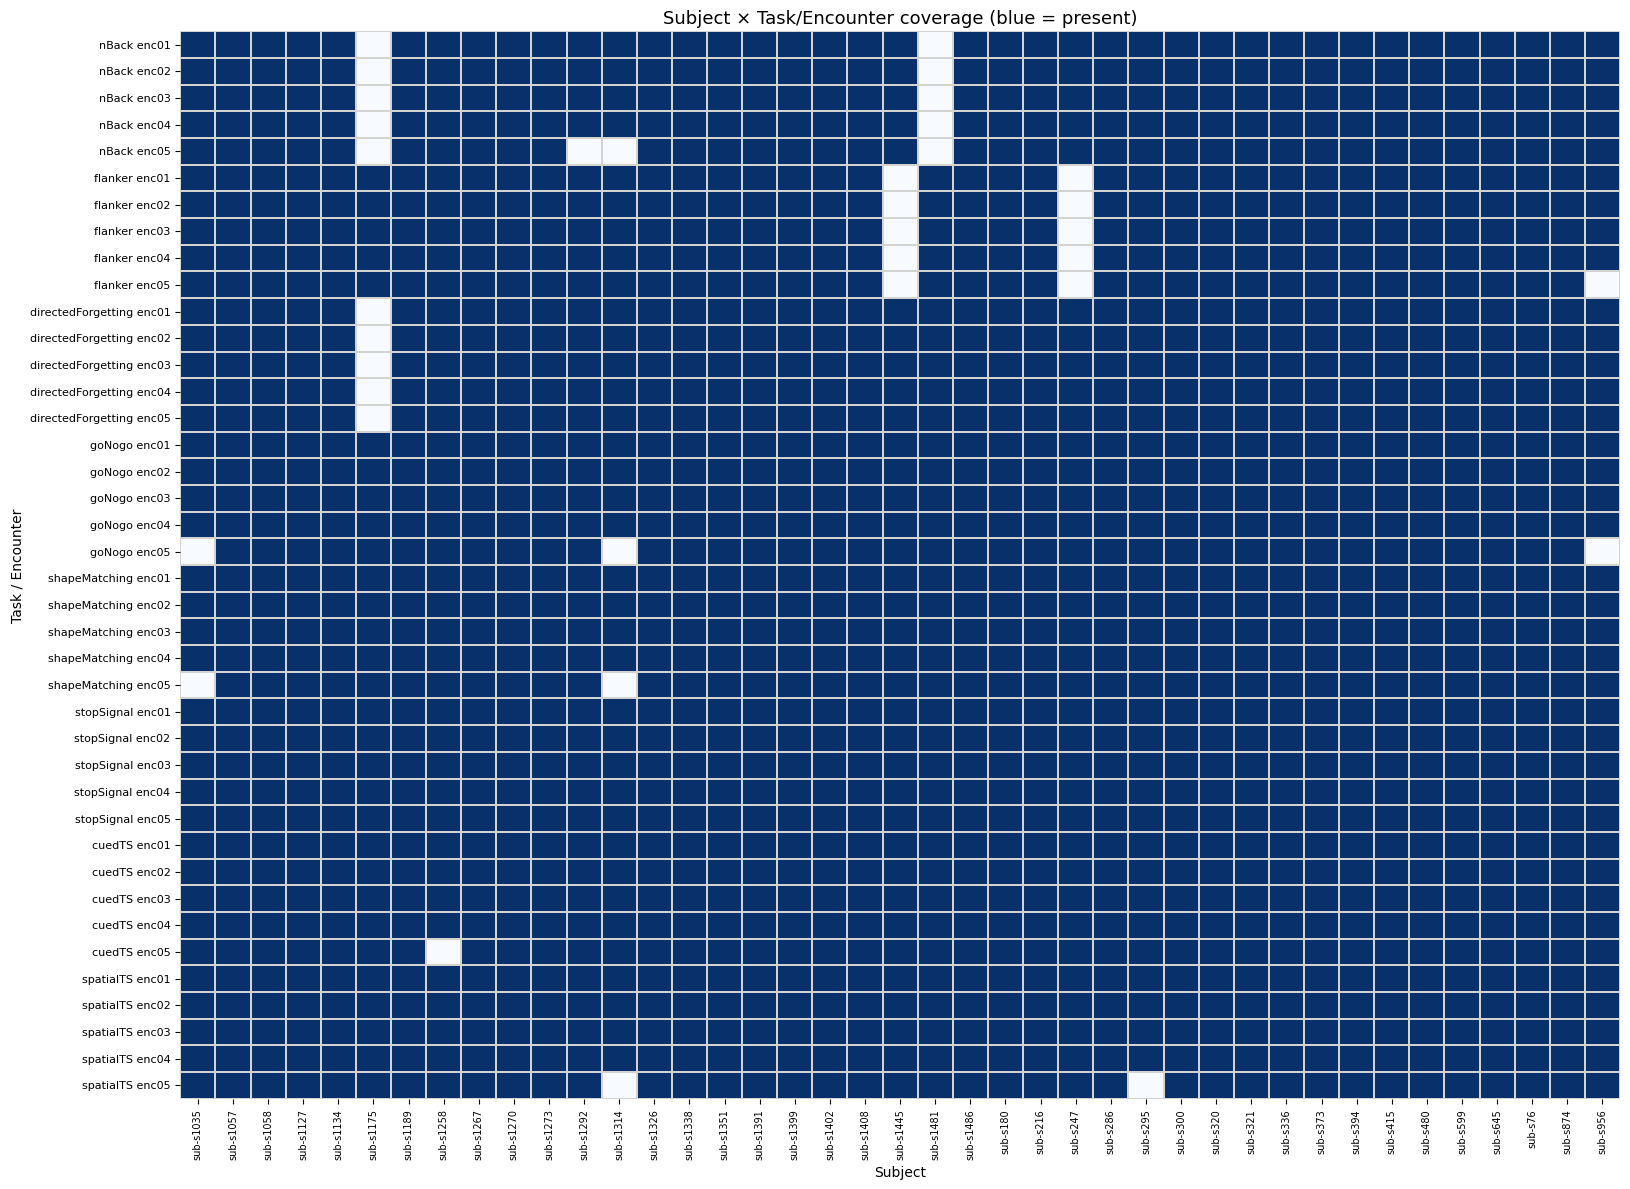

In [6]:
# Summarise at task×encounter level (collapse across contrasts within a task)
# A subject "has" a task/encounter if they have at least one contrast for it
task_enc_pairs = sorted(
    set((t, e) for t, c, e in all_tces),
    key=lambda te: (TASKS_OF_INTEREST.index(te[0]) if te[0] in TASKS_OF_INTEREST else 99, te[1])
)

te_coverage = pd.DataFrame(
    {
        sub: [
            int(any((t, c, e) in available_tce[sub] for t2, c, e2 in all_tces if t2 == t and e2 == e))
            for t, e in task_enc_pairs
        ]
        for sub in SUBJECTS
    },
    index=[f"{t} enc{e}" for t, e in task_enc_pairs]
)

fig, ax = plt.subplots(figsize=(max(14, len(SUBJECTS) * 0.4), max(6, len(task_enc_pairs) * 0.3)))
sns.heatmap(
    te_coverage,
    ax=ax,
    cmap="Blues",
    linewidths=0.3,
    linecolor="lightgray",
    cbar=False,
    vmin=0, vmax=1,
    annot=False,
)
ax.set_title("Subject × Task/Encounter coverage (blue = present)", fontsize=13)
ax.set_xlabel("Subject")
ax.set_ylabel("Task / Encounter")
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.show()


## 5. How many encounters per task are shared across all subjects?

In [7]:
summary_rows = []
for task in TASKS_OF_INTEREST:
    task_tces = [tce for tce in shared_tce_sorted if tce[0] == task]
    encounters = sorted(set(e for _, _, e in task_tces))
    contrasts = sorted(set(c for _, c, _ in task_tces))
    summary_rows.append({
        "task": task,
        "shared_encounters": len(encounters),
        "shared_contrasts": len(contrasts),
        "total_shared_tces": len(task_tces),
        "encounter_list": ", ".join(encounters),
        "contrast_list": "\n".join(contrasts),
    })

summary_df = pd.DataFrame(summary_rows).set_index("task")
print(summary_df[["shared_encounters", "shared_contrasts", "total_shared_tces", "encounter_list"]].to_string())
print()
print("Contrasts per task:")
for task, row in summary_df.iterrows():
    print(f"\n  {task}:")
    for c in row["contrast_list"].split("\n"):
        print(f"    - {c}")


                    shared_encounters  shared_contrasts  total_shared_tces      encounter_list
task                                                                                          
nBack                               0                 0                  0                    
flanker                             0                 0                  0                    
directedForgetting                  0                 0                  0                    
goNogo                              4                 4                 16      01, 02, 03, 04
shapeMatching                       4                 9                 36      01, 02, 03, 04
stopSignal                          5                 8                 40  01, 02, 03, 04, 05
cuedTS                              4                 4                 16      01, 02, 03, 04
spatialTS                           4                 4                 16      01, 02, 03, 04

Contrasts per task:

  nBack:
    - 

  flanker:


## 6. Which subjects are missing which tasks entirely?

In [8]:
print("Subjects missing at least one task entirely:")
any_missing = False
for sub in SUBJECTS:
    sub_tasks = set(t for t, c, e in available_tce[sub])
    missing = [t for t in TASKS_OF_INTEREST if t not in sub_tasks]
    if missing:
        print(f"  {sub}: missing {missing}")
        any_missing = True
if not any_missing:
    print("  None — all subjects have data for all 8 tasks")

print("\nSubjects with fewer than 5 encounters for any task:")
for sub in SUBJECTS:
    for task in TASKS_OF_INTEREST:
        encs = sorted(set(e for t, c, e in available_tce[sub] if t == task))
        if encs and len(encs) < 5:
            print(f"  {sub} / {task}: only {len(encs)} encounters ({', '.join(encs)})")


Subjects missing at least one task entirely:
  sub-s1175: missing ['nBack', 'directedForgetting']
  sub-s1445: missing ['flanker']
  sub-s1481: missing ['nBack']
  sub-s247: missing ['flanker']

Subjects with fewer than 5 encounters for any task:
  sub-s1035 / goNogo: only 4 encounters (01, 02, 03, 04)
  sub-s1035 / shapeMatching: only 4 encounters (01, 02, 03, 04)
  sub-s1258 / cuedTS: only 4 encounters (01, 02, 03, 04)
  sub-s1292 / nBack: only 4 encounters (01, 02, 03, 04)
  sub-s1314 / nBack: only 4 encounters (01, 02, 03, 04)
  sub-s1314 / goNogo: only 4 encounters (01, 02, 03, 04)
  sub-s1314 / shapeMatching: only 4 encounters (01, 02, 03, 04)
  sub-s1314 / spatialTS: only 4 encounters (01, 02, 03, 04)
  sub-s295 / spatialTS: only 4 encounters (01, 02, 03, 04)
  sub-s956 / flanker: only 4 encounters (01, 02, 03, 04)
  sub-s956 / goNogo: only 4 encounters (01, 02, 03, 04)


## 7. Full list: every (task, contrast, encounter) present in ALL subjects

In [9]:
current_task = None
for task, contrast, enc in shared_tce_sorted:
    if task != current_task:
        print(f"\n{'='*60}")
        print(f"  {task}")
        print(f"{'='*60}")
        current_task = task
    print(f"  enc {enc}  |  {contrast}")

print(f"\nTotal: {len(shared_tce_sorted)} TCEs shared across all {len(SUBJECTS)} subjects")



  goNogo
  enc 01  |  go
  enc 02  |  go
  enc 03  |  go
  enc 04  |  go
  enc 01  |  nogo_success
  enc 02  |  nogo_success
  enc 03  |  nogo_success
  enc 04  |  nogo_success
  enc 01  |  nogo_success-go
  enc 02  |  nogo_success-go
  enc 03  |  nogo_success-go
  enc 04  |  nogo_success-go
  enc 01  |  task-baseline
  enc 02  |  task-baseline
  enc 03  |  task-baseline
  enc 04  |  task-baseline

  shapeMatching
  enc 01  |  DDD
  enc 02  |  DDD
  enc 03  |  DDD
  enc 04  |  DDD
  enc 01  |  DDS
  enc 02  |  DDS
  enc 03  |  DDS
  enc 04  |  DDS
  enc 01  |  DNN
  enc 02  |  DNN
  enc 03  |  DNN
  enc 04  |  DNN
  enc 01  |  DSD
  enc 02  |  DSD
  enc 03  |  DSD
  enc 04  |  DSD
  enc 01  |  SDD
  enc 02  |  SDD
  enc 03  |  SDD
  enc 04  |  SDD
  enc 01  |  SNN
  enc 02  |  SNN
  enc 03  |  SNN
  enc 04  |  SNN
  enc 01  |  SSS
  enc 02  |  SSS
  enc 03  |  SSS
  enc 04  |  SSS
  enc 01  |  main_vars
  enc 02  |  main_vars
  enc 03  |  main_vars
  enc 04  |  main_vars
  enc 01  |  

## 8. TCEs missing for at least one subject

In [10]:
partial_tces = sorted(
    [tce for tce in all_tces if tce not in shared_tce],
    key=lambda tce: (
        TASKS_OF_INTEREST.index(tce[0]) if tce[0] in TASKS_OF_INTEREST else 99,
        tce[1], tce[2]
    )
)

print(f"TCEs present in SOME but not ALL subjects: {len(partial_tces)}\n")

current_task = None
for task, contrast, enc in partial_tces:
    if task != current_task:
        print(f"\n{'='*60}")
        print(f"  {task}")
        print(f"{'='*60}")
        current_task = task
    missing_subs = [s for s in SUBJECTS if (task, contrast, enc) not in available_tce[s]]
    n_have = len(SUBJECTS) - len(missing_subs)
    print(f"  enc {enc}  |  {contrast}")
    print(f"           {n_have}/{len(SUBJECTS)} subjects have it — missing: {', '.join(missing_subs)}")


TCEs present in SOME but not ALL subjects: 56


  nBack
  enc 01  |  match-mismatch
           39/41 subjects have it — missing: sub-s1175, sub-s1481
  enc 02  |  match-mismatch
           39/41 subjects have it — missing: sub-s1175, sub-s1481
  enc 03  |  match-mismatch
           39/41 subjects have it — missing: sub-s1175, sub-s1481
  enc 04  |  match-mismatch
           39/41 subjects have it — missing: sub-s1175, sub-s1481
  enc 05  |  match-mismatch
           37/41 subjects have it — missing: sub-s1175, sub-s1292, sub-s1314, sub-s1481
  enc 01  |  task-baseline
           39/41 subjects have it — missing: sub-s1175, sub-s1481
  enc 02  |  task-baseline
           39/41 subjects have it — missing: sub-s1175, sub-s1481
  enc 03  |  task-baseline
           39/41 subjects have it — missing: sub-s1175, sub-s1481
  enc 04  |  task-baseline
           39/41 subjects have it — missing: sub-s1175, sub-s1481
  enc 05  |  task-baseline
           37/41 subjects have it — missing: sub-s117